# Model Comparison V4 - Rule-Based Voting (Signal Aggregation)

## Concept

In plaats van numerieke features in een ML model te stoppen, vertalen we
elke factor naar een **discreet signaal**:

| Signaal      | Betekenis        |
|--------------|------------------|
| **+1**       | indicatie voor stijging |
| **0**        | neutraal / geen indicatie |
| **-1**       | indicatie voor daling |

De finale voorspelling is een **weighted majority vote**: elke factor draagt
bij naar zijn gewicht (technische signalen meer dan macro, sentiment gewogen
naar impact-score per stock). Vote score > 0 -> UP, anders DOWN.

## Waarom doen we dit naast de ML modellen?

1. **Interpretability** - elke voorspelling is volledig uit te leggen:
   "Het model voorspelde AAPL omhoog omdat: RSI oversold (+1), Twitter sentiment
   positief (+1), VIX dalend (+1) -> 3 signalen voor stijging".
2. **Domeinkennis-demonstratie** - we coderen *waarom* een signaal werkt,
   niet alleen *dat* het werkt.
3. **Sanity check op ML** - als ML ongeveer hetzelfde scoort als simpele
   regels, weet je dat de markt grotendeels random is en dat ML niet
   structureel beter wordt door meer complexiteit.

## Wat we vergelijken

1. **Rule-based voting** (dit hoofdstuk) - hand-tuned weights
2. **ML baselines** - LogReg, Random Forest, XGBoost, LightGBM
3. **Hybrid model** - voeg de signalen als features toe aan XGBoost
4. **Voting met geleerde gewichten** (logistic regression op signalen) -
   wat zegt de data over welke gewichten optimaal zijn?

## Wat is hetzelfde als V3

- Database, queries, robuste joins
- VADER sentiment + tekst-features
- Impact scoring (sentence-transformer met TF-IDF fallback)
- Stock-aware sentiment aggregatie
- Engineered price features (RSI, Bollinger, returns, etc.)
- Tijds-gebaseerde train/val/test split

> **Tip**: voor je commit naar git, doe **Cell -> All Output -> Clear**
> in Jupyter zodat de file niet corrupteert door grote DataFrame outputs.

## 1. Setup

In [1]:
import os, sys, json, warnings, time, re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "comparison" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS = Path(PROJECT_ROOT) / "model" / "comparison" / "artifacts_v4"
PER_STOCK = ARTIFACTS / "per_stock"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
PER_STOCK.mkdir(parents=True, exist_ok=True)
print("Artifacts:", ARTIFACTS)

Artifacts: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v4


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, mean_absolute_error, brier_score_loss,
    confusion_matrix,
)
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

def _try_import(name):
    try: return __import__(name), True
    except ImportError: return None, False

xgb, HAS_XGB = _try_import("xgboost")
lgb, HAS_LGB = _try_import("lightgbm")
print(f"XGBoost:  {'OK' if HAS_XGB else 'MISSING'}")
print(f"LightGBM: {'OK' if HAS_LGB else 'MISSING'}")

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    HAS_VADER = True
    vader = SentimentIntensityAnalyzer()
except ImportError:
    HAS_VADER = False
    print("pip install vaderSentiment")

HAS_ST = False
try:
    from sentence_transformers import SentenceTransformer
    HAS_ST = True
except Exception as _e:
    print(f"sentence-transformers off ({type(_e).__name__}) - TF-IDF fallback")

print(f"VADER: {'OK' if HAS_VADER else 'MISSING'}  |  ST: {'OK' if HAS_ST else 'OFF'}")

XGBoost:  OK
LightGBM: OK
VADER: OK  |  ST: OK


## 2. Data laden (zelfde queries als V3)

In [3]:
from database.connectie.connectie import get_engine, getData
engine = get_engine()

def get_or_die(query, name):
    df = getData(engine=engine, query=query)
    if df is None: raise RuntimeError(f"Query '{name}' faalde")
    return df

SQL_MARKET = '''
SELECT m.DateKey, d.FullDateAlternateKey AS [Date],
       LTRIM(RTRIM(m.StockKey)) AS StockKey,
       COALESCE(NULLIF(LTRIM(RTRIM(s.StockName)),''), LTRIM(RTRIM(m.StockKey))) AS StockName,
       s.[Type] AS StockType,
       CAST(m.[Open] AS FLOAT) AS [Open], CAST(m.High AS FLOAT) AS High,
       CAST(m.Low AS FLOAT) AS Low, CAST(m.[Close] AS FLOAT) AS [Close],
       CAST(m.Volume AS FLOAT) AS Volume,
       CAST(e.USD AS FLOAT) AS USD, CAST(e.OIL AS FLOAT) AS OIL,
       CAST(e.VIX AS FLOAT) AS VIX, CAST(e.YieldSpread AS FLOAT) AS YieldSpread,
       CAST(e.InfExpectation AS FLOAT) AS InfExpectation,
       CAST(e.FinStress AS FLOAT) AS FinStress,
       CAST(e.FedFundsRate AS FLOAT) AS FedFundsRate,
       CAST(e.FedBalanceSheet AS FLOAT) AS FedBalanceSheet,
       CAST(e.CPI AS FLOAT) AS CPI, CAST(e.PPI AS FLOAT) AS PPI,
       CAST(e.Consumer_Confidence AS FLOAT) AS Consumer_Confidence
FROM FactMarketData m
JOIN DimDate d ON d.DateKey = m.DateKey
LEFT JOIN DimStock s ON LTRIM(RTRIM(s.StockKey)) = LTRIM(RTRIM(m.StockKey))
LEFT JOIN FactEcon e ON e.DateKey = m.DateKey
WHERE m.StockKey IS NOT NULL AND LEN(LTRIM(RTRIM(m.StockKey))) > 0
ORDER BY m.StockKey, d.FullDateAlternateKey
'''
SQL_TWEETS = '''
SELECT d.FullDateAlternateKey AS [Date], t.[Text],
       COALESCE(CAST(t.influenceScore AS FLOAT), 0) AS influence
FROM DimTwitter t JOIN DimDate d ON d.DateKey = t.DateKey
WHERE t.[Text] IS NOT NULL AND LEN(t.[Text]) > 0
'''
SQL_NEWS = '''
SELECT d.FullDateAlternateKey AS [Date],
       COALESCE(n.Headline, '') + ' ' + COALESCE(n.Abstract, '') AS [Text],
       COALESCE(CAST(n.influenceScore AS FLOAT), 0) AS influence
FROM FactNews n JOIN DimDate d ON d.DateKey = n.DateKey
WHERE (n.Headline IS NOT NULL OR n.Abstract IS NOT NULL)
'''
market_df = get_or_die(SQL_MARKET, "market")
tweets_df = get_or_die(SQL_TWEETS, "tweets").reset_index(drop=True)
news_df   = get_or_die(SQL_NEWS,   "news").reset_index(drop=True)
for d_ in (market_df, tweets_df, news_df):
    d_["Date"] = pd.to_datetime(d_["Date"])
market_df["stock_id"] = market_df["StockName"].fillna(market_df["StockKey"]).astype(str)
print(f"market: {len(market_df):,}  tweets: {len(tweets_df):,}  news: {len(news_df):,}")
print(f"Stocks: {market_df['stock_id'].nunique()}")

market: 26,224  tweets: 26,181  news: 253,001
Stocks: 10


## 3. VADER sentiment scoring (zelfde als V3)

In [4]:
BULLISH = {"rally","surge","beat","upgrade","outperform","bullish","growth","soar","jump","gain","record","strong","profit"}
BEARISH = {"crash","plunge","miss","downgrade","underperform","bearish","decline","fall","drop","loss","weak","warning","lawsuit","investigation","default","bankruptcy"}
TICKER_RE = re.compile(r"\$[A-Z]{1,5}\b")
WORD_RE   = re.compile(r"\b[a-zA-Z']+\b")

def text_features(t):
    if not isinstance(t, str) or not t:
        return {"v_compound":0,"v_pos":0,"v_neg":0,"v_neu":1,"n_bull":0,"n_bear":0}
    v = vader.polarity_scores(t) if HAS_VADER else {"compound":0,"pos":0,"neg":0,"neu":1}
    lower = t.lower()
    return {"v_compound":v["compound"],"v_pos":v["pos"],"v_neg":v["neg"],"v_neu":v["neu"],
            "n_bull":sum(1 for kw in BULLISH if kw in lower),
            "n_bear":sum(1 for kw in BEARISH if kw in lower)}

def score_df(df):
    feats = pd.DataFrame.from_records(df["Text"].map(text_features).tolist(), index=df.index)
    return pd.concat([df, feats], axis=1)

print("Scoring tweets..."); tweets_scored = score_df(tweets_df)
print("Scoring news...");   news_scored   = score_df(news_df)
print(f"Scored: tweets={len(tweets_scored):,}  news={len(news_scored):,}")

Scoring tweets...
Scoring news...
Scored: tweets=26,181  news=253,001


## 4. Stock-tweet impact scoring

In [5]:
stocks_meta = market_df.groupby("stock_id").first()[["StockKey","StockName","StockType"]].reset_index().fillna("")

def stock_descriptor(row):
    parts = []
    if row["StockName"]: parts.append(str(row["StockName"]))
    if row["StockKey"] and row["StockKey"] != row["StockName"]:
        parts.append(f"ticker symbol {row['StockKey']}")
    if row["StockType"]: parts.append(f"type {row['StockType']}")
    parts.append("stock financial market")
    return " ".join(p.strip() for p in parts if p)

stocks_meta["descriptor"] = stocks_meta.apply(stock_descriptor, axis=1)
n_stocks = len(stocks_meta)
n_tweets = len(tweets_df)

# Compute impact matrix (sentence-transformer or TF-IDF fallback)
impact = None
if HAS_ST:
    try:
        st_model = SentenceTransformer("all-MiniLM-L6-v2")
        stock_emb = st_model.encode(stocks_meta["descriptor"].tolist(), normalize_embeddings=True, show_progress_bar=False)
        tweet_emb = st_model.encode(tweets_df["Text"].tolist(), normalize_embeddings=True, batch_size=64, show_progress_bar=True)
        impact = np.clip(tweet_emb @ stock_emb.T, 0, 1).astype(np.float32)
        method = "sentence-transformer"
    except Exception:
        HAS_ST = False

if impact is None:
    print("TF-IDF cosine similarity scoring...")
    all_texts = list(tweets_df["Text"].fillna("")) + list(stocks_meta["descriptor"])
    tfidf = TfidfVectorizer(lowercase=True, ngram_range=(1,2), max_features=20_000, min_df=2, stop_words="english").fit(all_texts)
    tweet_tfidf = tfidf.transform(tweets_df["Text"].fillna(""))
    stock_tfidf = tfidf.transform(stocks_meta["descriptor"])
    impact = np.clip(sk_cosine(tweet_tfidf, stock_tfidf), 0, 1).astype(np.float32)
    method = "tf-idf"

# Direct mention boost
tweet_texts_lower = tweets_df["Text"].fillna("").str.lower()
for j, row in stocks_meta.iterrows():
    keys = []
    if row["StockKey"]: keys.append(re.escape(str(row["StockKey"]).lower()))
    if row["StockName"]:
        for word in re.findall(r"\b[A-Za-z]{3,}\b", str(row["StockName"])):
            if word.lower() not in {"the","inc","ltd","corp","plc","group","company","stock","etf","index"}:
                keys.append(re.escape(word.lower()))
    if keys:
        pattern = r"(?:^|[^a-z])(" + "|".join(set(keys)) + r")(?:[^a-z]|$)"
        has_mention = tweet_texts_lower.str.contains(pattern, regex=True, na=False).values
        impact[has_mention, j] = np.maximum(impact[has_mention, j], 0.95)

print(f"Method: {method}")
print(f"Impact matrix: {impact.shape}, mean={impact.mean():.3f}")

Batches: 100%|██████████| 410/410 [03:23<00:00,  2.02it/s]


Method: sentence-transformer
Impact matrix: (26181, 10), mean=0.043


## 5. Stock-aware sentiment aggregatie (per stock per dag)

In [6]:
tweets_scored["dnorm"] = tweets_scored["Date"].dt.normalize()
per_stock_records = []
for j, row in stocks_meta.iterrows():
    sid = row["stock_id"]
    w = impact[:, j].astype(np.float64)
    sub = tweets_scored.copy()
    sub["w"] = w
    sub["w_compound"] = sub["v_compound"] * w
    sub["w_bull"] = sub["n_bull"] * w
    sub["w_bear"] = sub["n_bear"] * w
    g = sub.groupby("dnorm").agg(
        sum_w=("w","sum"), n_items=("w","size"),
        sum_w_compound=("w_compound","sum"),
        sum_w_bull=("w_bull","sum"),
        sum_w_bear=("w_bear","sum"),
        max_w=("w","max"),
    ).reset_index()
    eps = 1e-6
    g["tw_compound_wmean"] = g["sum_w_compound"] / (g["sum_w"] + eps)
    g["tw_bull_w"] = g["sum_w_bull"]
    g["tw_bear_w"] = g["sum_w_bear"]
    g["tw_max_impact"] = g["max_w"]
    g["tw_n_items"] = g["n_items"]
    g["stock_id"] = sid
    per_stock_records.append(g[["dnorm","stock_id","tw_compound_wmean","tw_bull_w",
                                 "tw_bear_w","tw_max_impact","tw_n_items"]].rename(columns={"dnorm":"Date"}))
tw_per_stock = pd.concat(per_stock_records, ignore_index=True)

# News market-wide
news_scored["dnorm"] = news_scored["Date"].dt.normalize()
g_news = news_scored.groupby("dnorm")
news_daily = pd.DataFrame({
    "news_compound_mean": g_news["v_compound"].mean(),
    "news_bull_sum":      g_news["n_bull"].sum(),
    "news_bear_sum":      g_news["n_bear"].sum(),
    "news_n_items":       g_news.size(),
}).reset_index().rename(columns={"dnorm":"Date"})
print(f"tw_per_stock: {tw_per_stock.shape}, news_daily: {news_daily.shape}")

tw_per_stock: (13690, 7), news_daily: (3765, 5)


## 6. Joinen + technische indicators

In [7]:
df = market_df.merge(tw_per_stock, on=["Date","stock_id"], how="left")
df = df.merge(news_daily, on="Date", how="left")
sent_cols = [c for c in df.columns if c.startswith(("tw_","news_"))]
df[sent_cols] = df.sort_values(["stock_id","Date"]).groupby("stock_id")[sent_cols].ffill().fillna(0)

def add_engineered(g):
    g = g.sort_values("Date").copy()
    c = g["Close"]
    g["log_return"] = np.log(c / c.shift(1))
    g["return_5d"] = c.pct_change(5)
    g["return_10d"] = c.pct_change(10)
    g["rolling_std_5"] = c.rolling(5).std()
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    g["rsi_14"] = (100 - 100/(1 + gain / loss.replace(0,np.nan))).fillna(50)
    m20 = c.rolling(20).mean(); s20 = c.rolling(20).std().replace(0,np.nan)
    g["bollinger_pos"] = ((c - m20)/s20).fillna(0)
    v = g["Volume"]
    g["vol_zscore"] = ((v - v.rolling(20).mean()) / v.rolling(20).std().replace(0,np.nan)).fillna(0)
    # Macro deltas (5-day rate of change voor de macro-feature signalen)
    for col in ["VIX","USD","YieldSpread","Consumer_Confidence"]:
        if col in g.columns:
            g[f"{col}_delta_5d"] = g[col].diff(5)
    return g

_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_engineered(_g); _g2["stock_id"] = _sid
    _out.append(_g2)
df = pd.concat(_out, ignore_index=True)
print(f"df shape: {df.shape}")

df shape: (26224, 42)


## 7. Binary target

In [8]:
HORIZON = 1
def add_target(g):
    g = g.sort_values("Date").copy()
    fut = g["Close"].shift(-HORIZON)
    g["y_return"] = fut / g["Close"] - 1
    g["target"] = (g["y_return"] > 0).astype(float)
    g.loc[fut.isna(), ["target","y_return"]] = np.nan
    return g
_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_target(_g); _g2["stock_id"] = _sid; _out.append(_g2)
df = pd.concat(_out, ignore_index=True).dropna(subset=["target"]).reset_index(drop=True)
df["target"] = df["target"].astype(int)
print(f"Final df: {df.shape}, class balance: {df['target'].mean():.3f}")

Final df: (26189, 44), class balance: 0.526


## 8. Signaal definities  *(KERN VAN V4)*

We zetten elke factor om naar een **discreet signaal** in {-1, 0, +1}.
Onder elke regel staat de **rationale** uit de literatuur waarom dit signaal
zou moeten werken.

### Technische signalen (sterk; gewicht 1.5 - 2.0)

| Signaal              | Regel                          | Rationale |
|----------------------|--------------------------------|-----------|
| `sig_rsi`            | RSI<30 -> +1, RSI>70 -> -1     | Mean reversion: oversold gaat omhoog, overbought corrigeert |
| `sig_bollinger`      | bp<-1.5 -> +1, bp>1.5 -> -1    | Idem maar volatility-genormaliseerd |
| `sig_return_5d`      | ret>+0.5% -> +1, <-0.5% -> -1  | Momentum: trend op 5d duurt typisch enkele dagen door |
| `sig_return_10d`     | idem op 10d                    | Langer-momentum confirmatie |
| `sig_volume_confirm` | high vol + up dag -> +1, idem -1 | Volume bevestigt prijsbeweging |

### Sentiment signalen (medium; gewicht 1.0 - 1.5, gewogen naar impact)

| Signaal              | Regel                          | Rationale |
|----------------------|--------------------------------|-----------|
| `sig_tw_compound`    | tw_compound>0.15 -> +1, <-0.15 -> -1 | Twitter sentiment voorspelt korte-termijn prijs |
| `sig_tw_bull_bear`   | bull > bear -> +1, bear > bull -> -1 | Hoeveel bull/bear keywords vaker voorkomen |
| `sig_news_compound`  | news>0.15 -> +1, <-0.15 -> -1  | Nieuws-sentiment, market-wide |

### Macro signalen (zwak; gewicht 0.3 - 0.5, market-wide)

| Signaal              | Regel                          | Rationale |
|----------------------|--------------------------------|-----------|
| `sig_vix_delta`      | VIX stijgt -> -1, daalt -> +1  | Fear index: stijging = risk-off |
| `sig_usd_delta`      | USD stijgt -> -1, daalt -> +1  | Sterke dollar drukt aandelen |
| `sig_yield_delta`    | yield spread daalt -> -1       | Inverterende curve = recessie-risico |
| `sig_consumer_conf`  | conf stijgt -> +1, daalt -> -1 | Meer vertrouwen = meer consumptie/aandelen |

In [9]:
def to_signal(value, pos_thresh, neg_thresh):
    """Convert continuous value to {-1, 0, +1} signal."""
    return np.where(value > pos_thresh, 1, np.where(value < neg_thresh, -1, 0)).astype(int)

def compute_signals(df_in):
    s = df_in.copy()
    # Technical
    s["sig_rsi"]            = to_signal(-s["rsi_14"], -30, -70)  # invert: laag RSI = +1
    # Equivalent: rsi<30 -> +1, rsi>70 -> -1
    s["sig_rsi"]            = np.where(s["rsi_14"] < 30, 1,
                                        np.where(s["rsi_14"] > 70, -1, 0)).astype(int)
    s["sig_bollinger"]      = np.where(s["bollinger_pos"] < -1.5, 1,
                                        np.where(s["bollinger_pos"] > 1.5, -1, 0)).astype(int)
    s["sig_return_5d"]      = to_signal(s["return_5d"].fillna(0),  0.005, -0.005)
    s["sig_return_10d"]     = to_signal(s["return_10d"].fillna(0), 0.01, -0.01)
    # Volume confirmation
    high_vol = s["vol_zscore"].fillna(0) > 1.0
    pos_day = s["log_return"].fillna(0) > 0
    s["sig_volume_confirm"] = np.where(high_vol & pos_day, 1,
                                        np.where(high_vol & (~pos_day), -1, 0)).astype(int)
    # Sentiment per stock
    s["sig_tw_compound"]    = to_signal(s["tw_compound_wmean"].fillna(0), 0.15, -0.15)
    bull_minus_bear         = s["tw_bull_w"].fillna(0) - s["tw_bear_w"].fillna(0)
    s["sig_tw_bull_bear"]   = to_signal(bull_minus_bear, 0.5, -0.5)
    s["sig_news_compound"]  = to_signal(s["news_compound_mean"].fillna(0), 0.15, -0.15)
    # Macro
    s["sig_vix_delta"]      = to_signal(-s.get("VIX_delta_5d", pd.Series(0, index=s.index)).fillna(0), 0.5, -0.5)
    s["sig_usd_delta"]      = to_signal(-s.get("USD_delta_5d", pd.Series(0, index=s.index)).fillna(0), 0.5, -0.5)
    s["sig_yield_delta"]    = to_signal( s.get("YieldSpread_delta_5d", pd.Series(0, index=s.index)).fillna(0), 0.05, -0.05)
    s["sig_consumer_conf"]  = to_signal( s.get("Consumer_Confidence_delta_5d", pd.Series(0, index=s.index)).fillna(0), 0.5, -0.5)
    return s

df = compute_signals(df)
SIGNAL_COLS = [c for c in df.columns if c.startswith("sig_")]
print(f"Signalen: {SIGNAL_COLS}")
print(f"Dataframe na signalen: {df.shape}")

Signalen: ['sig_rsi', 'sig_bollinger', 'sig_return_5d', 'sig_return_10d', 'sig_volume_confirm', 'sig_tw_compound', 'sig_tw_bull_bear', 'sig_news_compound', 'sig_vix_delta', 'sig_usd_delta', 'sig_yield_delta', 'sig_consumer_conf']
Dataframe na signalen: (26189, 56)


### Visualisatie 1: Verdeling van elk signaal

We willen weten of onze drempels redelijk zijn. Een goed signaal heeft
significante mass in **alle drie** klassen (-1/0/+1). Een signaal dat altijd
op 0 staat geeft geen informatie.

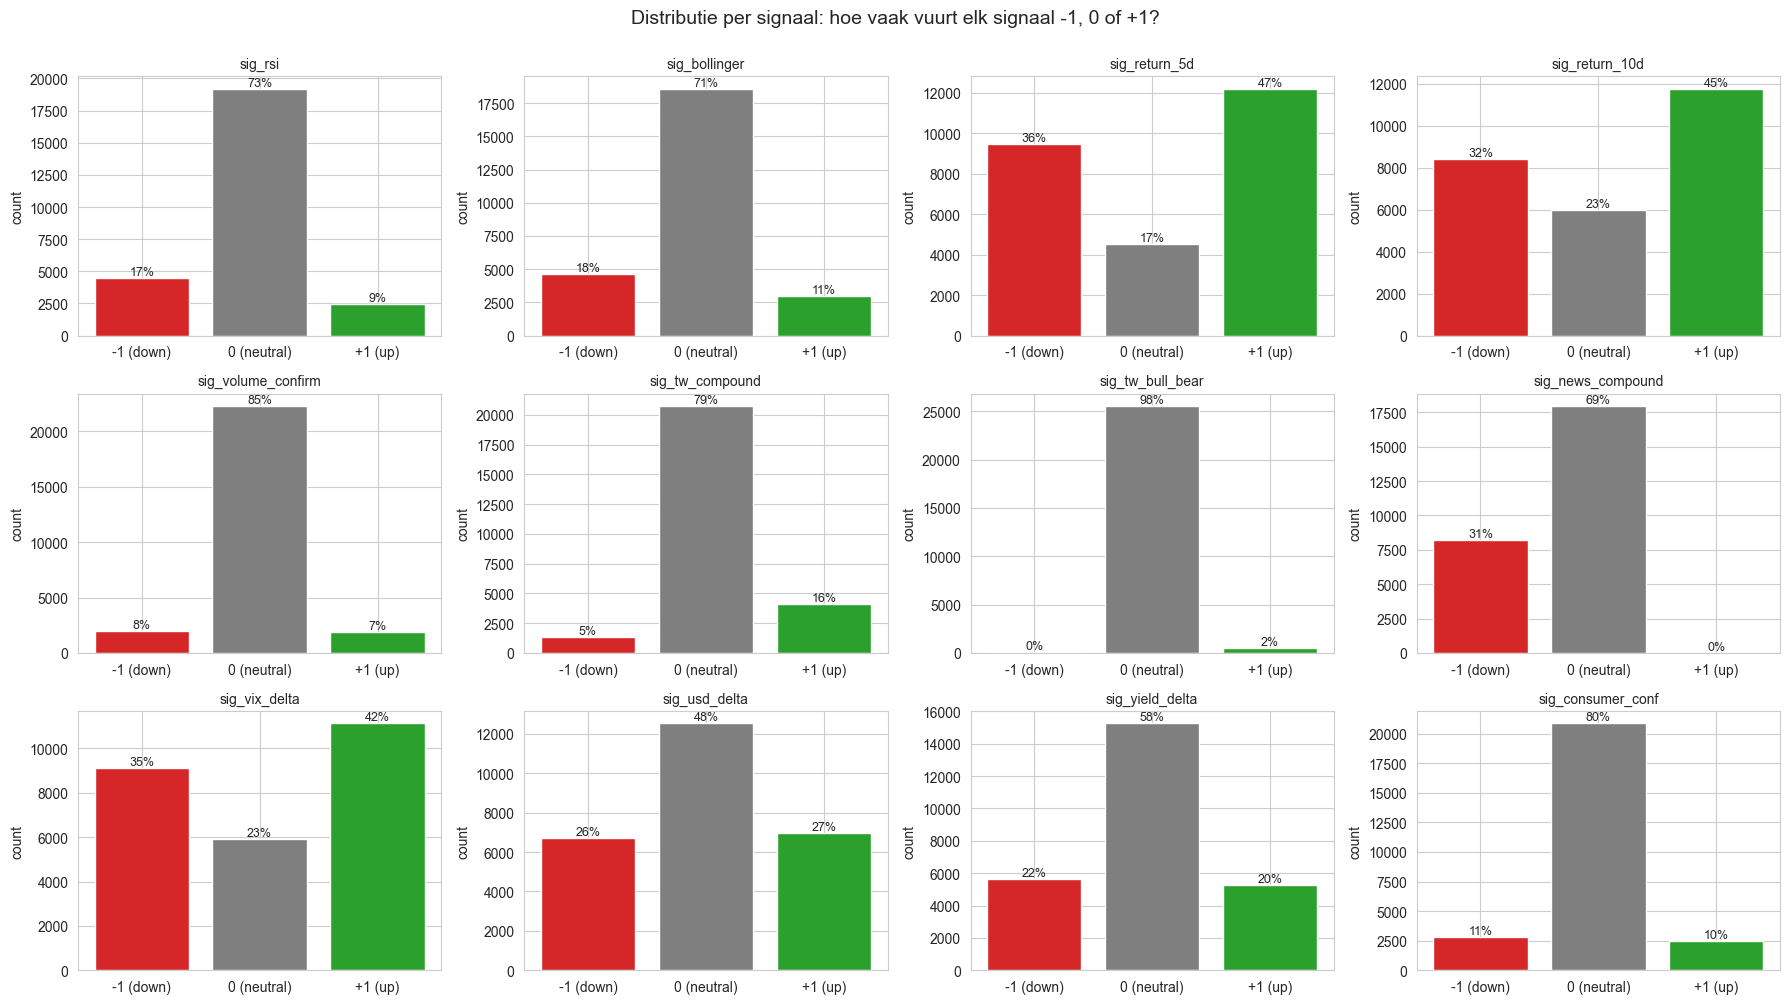

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v4\signal_distributions.png


In [10]:
# Distribution per signal
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, sig in enumerate(SIGNAL_COLS):
    if i >= len(axes): break
    counts = df[sig].value_counts().sort_index().reindex([-1, 0, 1], fill_value=0)
    colors = ["#d62728", "#7f7f7f", "#2ca02c"]
    axes[i].bar(["-1 (down)", "0 (neutral)", "+1 (up)"], counts.values, color=colors)
    axes[i].set_title(sig, fontsize=10)
    axes[i].set_ylabel("count")
    for j, v in enumerate(counts.values):
        axes[i].text(j, v, f"{v/counts.sum()*100:.0f}%", ha="center", va="bottom", fontsize=9)
for ax in axes[len(SIGNAL_COLS):]:
    ax.axis("off")
plt.suptitle("Distributie per signaal: hoe vaak vuurt elk signaal -1, 0 of +1?", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(ARTIFACTS / "signal_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {ARTIFACTS / 'signal_distributions.png'}")

**Inzicht uit deze grafiek**:
- Signalen met >70% nullen geven beperkt informatie - drempels evt versoepelen
- Signalen die ofwel +1 of -1 *bijna nooit* vuren zijn asymmetrisch en kunnen bias introduceren
- Sentiment signalen zijn vaak grotendeels 0 omdat de meeste dagen geen extreme sentiment hebben

## 9. Welke signalen voorspellen écht?

Voor elk signaal: wat is de hit rate (= P(target=1 | sig=+1)) en P(target=0 | sig=-1)?
Een signaal werkt als beide kansen significant hoger zijn dan de baseline (~0.5).

In [11]:
baseline = df["target"].mean()
print(f"Baseline (P(up)): {baseline:.3f}")

rows = []
for sig in SIGNAL_COLS:
    pos_mask = df[sig] == 1
    neg_mask = df[sig] == -1
    rows.append({
        "signal": sig,
        "n_pos": int(pos_mask.sum()),
        "P(up | sig=+1)": df.loc[pos_mask, "target"].mean() if pos_mask.sum() else np.nan,
        "n_neg": int(neg_mask.sum()),
        "P(up | sig=-1)": df.loc[neg_mask, "target"].mean() if neg_mask.sum() else np.nan,
    })
sig_quality = pd.DataFrame(rows)
sig_quality["edge_pos"] = sig_quality["P(up | sig=+1)"] - baseline
sig_quality["edge_neg"] = baseline - sig_quality["P(up | sig=-1)"]
sig_quality["total_edge"] = sig_quality["edge_pos"] + sig_quality["edge_neg"]
sig_quality = sig_quality.sort_values("total_edge", ascending=False).reset_index(drop=True)
sig_quality.to_csv(ARTIFACTS / "signal_quality.csv", index=False)
print(sig_quality.round(4).to_string(index=False))

Baseline (P(up)): 0.526
            signal  n_pos  P(up | sig=+1)  n_neg  P(up | sig=-1)  edge_pos  edge_neg  total_edge
 sig_news_compound     10          0.6000   8221          0.5137    0.0744    0.0119      0.0863
           sig_rsi   2484          0.5322   4502          0.5184    0.0066    0.0072      0.0138
   sig_tw_compound   4108          0.5297   1347          0.5197    0.0041    0.0059      0.0100
     sig_vix_delta  11129          0.5335   9137          0.5245    0.0079    0.0011      0.0090
sig_volume_confirm   1900          0.5232   2015          0.5226   -0.0024    0.0030      0.0006
   sig_yield_delta   5278          0.5324   5650          0.5322    0.0068   -0.0066      0.0002
     sig_usd_delta   6954          0.5246   6700          0.5272   -0.0010   -0.0016     -0.0026
    sig_return_10d  11774          0.5244   8406          0.5282   -0.0012   -0.0026     -0.0038
     sig_bollinger   2980          0.5211   4625          0.5250   -0.0045    0.0006     -0.0038
     s

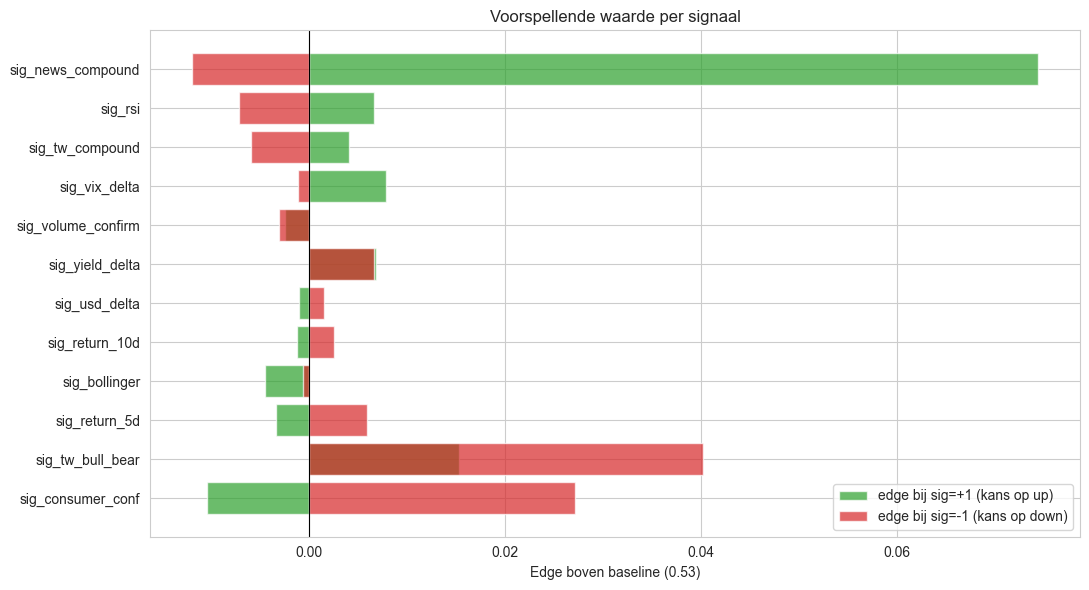

Saved: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v4\signal_edge.png


In [12]:
# Visualize signal edge
fig, ax = plt.subplots(figsize=(11, 6))
sig_q_sorted = sig_quality.sort_values("total_edge")
y = np.arange(len(sig_q_sorted))
ax.barh(y, sig_q_sorted["edge_pos"], color="#2ca02c", alpha=0.7, label="edge bij sig=+1 (kans op up)")
ax.barh(y, -sig_q_sorted["edge_neg"], color="#d62728", alpha=0.7, label="edge bij sig=-1 (kans op down)")
ax.set_yticks(y)
ax.set_yticklabels(sig_q_sorted["signal"])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"Edge boven baseline ({baseline:.2f})")
ax.set_title("Voorspellende waarde per signaal")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS / "signal_edge.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {ARTIFACTS / 'signal_edge.png'}")

**Inzicht**: signalen met **edge > 0.02** (2 procentpunten boven baseline) zijn
de moeite waard. Signalen met edge < 0.01 zijn waarschijnlijk ruis.

Een sterk signaal heeft edge **bij beide** kanten. Bv. RSI: oversold (sig=+1)
betekent vaker een up-dag, en overbought (sig=-1) betekent vaker een down-dag.
Als slechts één kant edge heeft is het signaal asymmetrisch en mogelijk
toevallig.

## 10. Signaalgewichten + voting predictor

Hand-tuned gewichten gebaseerd op de literatuur en signaal-quality (Sectie 9).
Sentiment signalen worden **per stock dynamisch gewogen** met de gemiddelde
impact-score voor die stock - dus tweets die over deze stock gaan tellen meer.

In [13]:
# Hand-tuned gewichten - gebaseerd op de signal_quality + literatuur priors
SIGNAL_WEIGHTS = {
    "sig_rsi":            2.0,
    "sig_bollinger":      1.5,
    "sig_return_5d":      1.5,
    "sig_return_10d":     1.0,
    "sig_volume_confirm": 1.0,
    "sig_tw_compound":    1.5,   # gewogen door tw_max_impact per rij
    "sig_tw_bull_bear":   1.0,   # gewogen door tw_max_impact per rij
    "sig_news_compound":  0.7,
    "sig_vix_delta":      0.5,
    "sig_usd_delta":      0.3,
    "sig_yield_delta":    0.5,
    "sig_consumer_conf":  0.4,
}

# Welke signalen schalen met impact-score (per stock dynamisch)?
IMPACT_SCALED = {"sig_tw_compound", "sig_tw_bull_bear"}

print("Signal weights:")
for k, v in sorted(SIGNAL_WEIGHTS.items(), key=lambda x: -x[1]):
    flag = "  <- impact-scaled" if k in IMPACT_SCALED else ""
    print(f"  {k:25s} = {v:.2f}{flag}")

Signal weights:
  sig_rsi                   = 2.00
  sig_bollinger             = 1.50
  sig_return_5d             = 1.50
  sig_tw_compound           = 1.50  <- impact-scaled
  sig_return_10d            = 1.00
  sig_volume_confirm        = 1.00
  sig_tw_bull_bear          = 1.00  <- impact-scaled
  sig_news_compound         = 0.70
  sig_vix_delta             = 0.50
  sig_yield_delta           = 0.50
  sig_consumer_conf         = 0.40
  sig_usd_delta             = 0.30


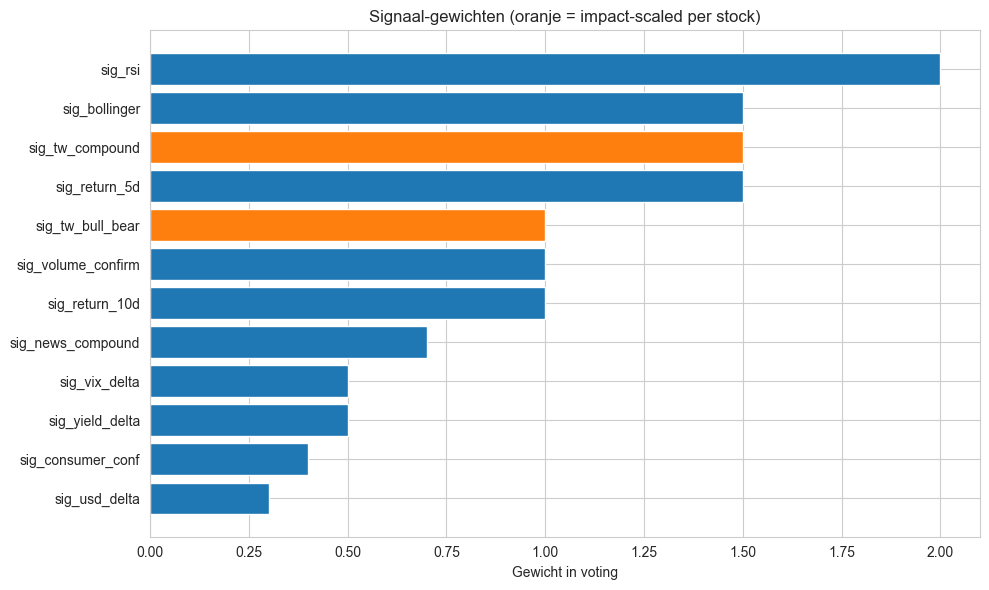

In [14]:
# Visualize weights
weight_df = pd.DataFrame([
    {"signal": k, "weight": v, "impact_scaled": k in IMPACT_SCALED}
    for k, v in SIGNAL_WEIGHTS.items()
]).sort_values("weight", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#ff7f0e" if x else "#1f77b4" for x in weight_df["impact_scaled"]]
ax.barh(weight_df["signal"], weight_df["weight"], color=colors)
ax.set_xlabel("Gewicht in voting")
ax.set_title("Signaal-gewichten (oranje = impact-scaled per stock)")
plt.tight_layout()
plt.savefig(ARTIFACTS / "signal_weights.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
def voting_predict(df_in, weights=SIGNAL_WEIGHTS, impact_scaled=IMPACT_SCALED):
    """Compute weighted vote score per row, return predictions + confidence."""
    score = np.zeros(len(df_in), dtype=np.float64)
    max_score = 0.0
    for sig, w in weights.items():
        if sig not in df_in.columns: continue
        if sig in impact_scaled and "tw_max_impact" in df_in.columns:
            # Scale weight by per-row tw_max_impact (clipped to [0.2, 1.0] zodat altijd minstens iets)
            row_w = w * np.clip(df_in["tw_max_impact"].fillna(0).values, 0.2, 1.0)
            score += df_in[sig].values * row_w
            max_score += w  # voor confidence normalisatie nemen we de max mogelijke bijdrage
        else:
            score += df_in[sig].values * w
            max_score += w
    pred = (score > 0).astype(int)
    # Sigmoid-style confidence: hoe sterker score afwijkt van 0, hoe hoger de confidence
    proba = 1 / (1 + np.exp(-score / max(max_score / 4, 1e-6)))
    return score, pred, proba

vote_score, vote_pred, vote_proba = voting_predict(df)
df["vote_score"] = vote_score
df["vote_pred"] = vote_pred
df["vote_proba"] = vote_proba
print(f"Voting predictions on full df:")
print(f"  predict UP:   {(vote_pred == 1).sum():,}  ({(vote_pred == 1).mean():.1%})")
print(f"  predict DOWN: {(vote_pred == 0).sum():,}  ({(vote_pred == 0).mean():.1%})")
print(f"  full-data accuracy (incl train): {(vote_pred == df['target'].values).mean():.3f}")

Voting predictions on full df:
  predict UP:   12,434  (47.5%)
  predict DOWN: 13,755  (52.5%)
  full-data accuracy (incl train): 0.501


## 11. Visualisatie: hoe stemt het model?

Voor één voorbeeldstock (eerste in de lijst): laat zien welke signalen
welke richting voteren over tijd, en hoe dat aggregeert tot een eindstem.

Voorbeeld: Anheuser-Busch InBev SA/NV (laatste 120 dagen)


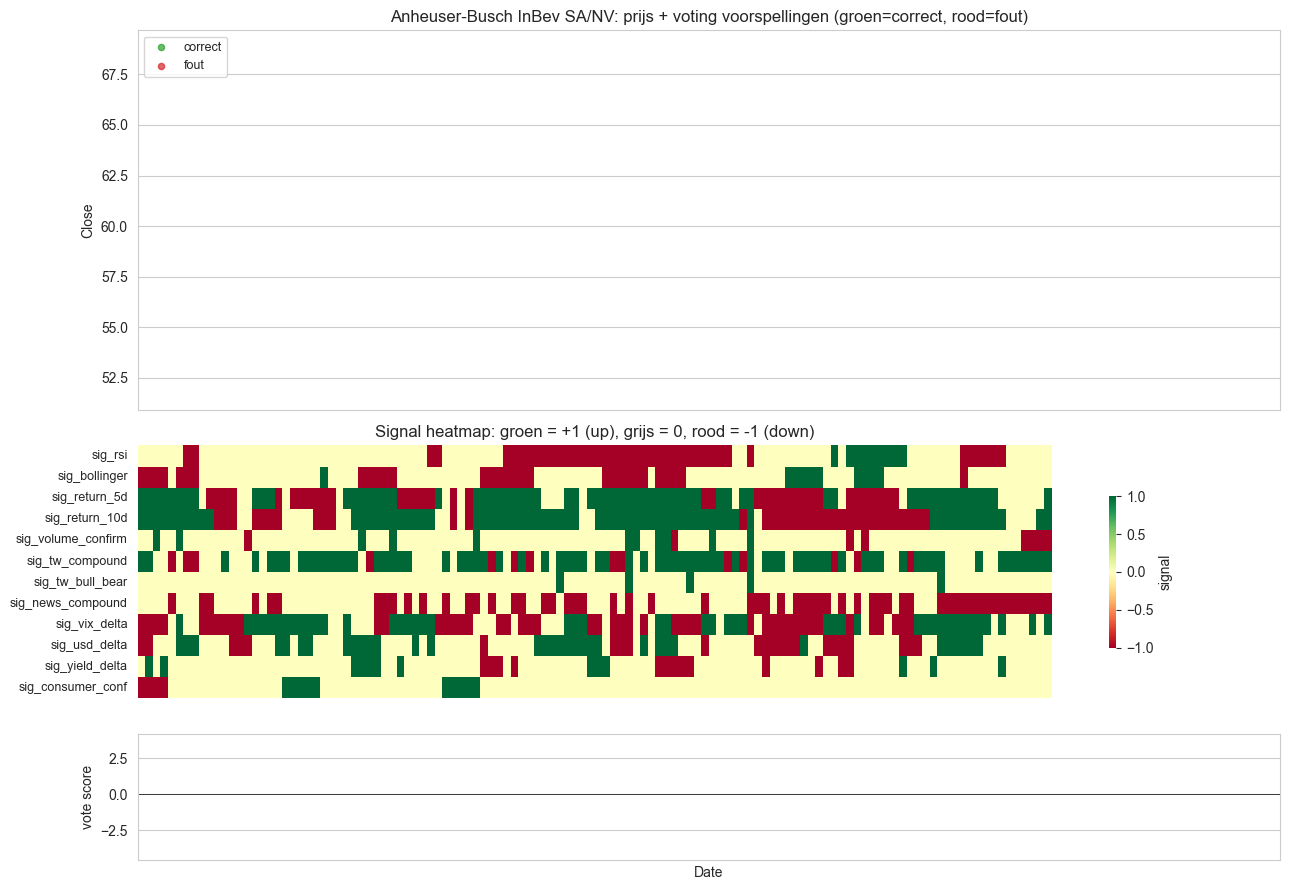

In [16]:
example_stock = sorted(df["stock_id"].unique())[0]
ex = df[df["stock_id"] == example_stock].sort_values("Date").tail(120).reset_index(drop=True)
print(f"Voorbeeld: {example_stock} (laatste {len(ex)} dagen)")

# Heatmap van signalen over tijd
fig, axes = plt.subplots(3, 1, figsize=(13, 9), gridspec_kw={"height_ratios":[3,2,1]}, sharex=True)

# Panel 1: close price + voorspellingen
ax = axes[0]
ax.plot(ex["Date"], ex["Close"], color="#222", lw=1.0)
correct = (ex["vote_pred"] == ex["target"])
ax.scatter(ex.loc[correct, "Date"],  ex.loc[correct, "Close"],  color="#2ca02c", s=20, alpha=0.7, label="correct")
ax.scatter(ex.loc[~correct,"Date"],  ex.loc[~correct,"Close"],  color="#d62728", s=20, alpha=0.7, label="fout")
ax.legend(loc="upper left", fontsize=9)
ax.set_ylabel("Close")
ax.set_title(f"{example_stock}: prijs + voting voorspellingen (groen=correct, rood=fout)")

# Panel 2: signal heatmap
sig_data = ex[SIGNAL_COLS].T
ax = axes[1]
sns.heatmap(sig_data, ax=ax, cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            cbar_kws={"label":"signal", "shrink":0.6}, xticklabels=False)
ax.set_yticklabels(SIGNAL_COLS, rotation=0, fontsize=9)
ax.set_title("Signal heatmap: groen = +1 (up), grijs = 0, rood = -1 (down)")
ax.set_ylabel("")

# Panel 3: vote score
ax = axes[2]
colors = ["#d62728" if v < 0 else "#2ca02c" for v in ex["vote_score"]]
ax.bar(ex["Date"], ex["vote_score"], color=colors, width=1.0, alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("vote score")
ax.set_xlabel("Date")

plt.tight_layout()
plt.savefig(ARTIFACTS / f"voting_in_action_{re.sub(r'[^A-Za-z0-9_-]', '_', example_stock)}.png",
            dpi=120, bbox_inches="tight")
plt.show()

**Wat je hier ziet**:
- **Bovenaan**: de daadwerkelijke prijs met groene/rode markers — correcte
  en foute voorspellingen.
- **Midden**: heatmap van alle signalen over tijd. Groene cellen vuren +1,
  rode cellen vuren -1, grijze zijn neutraal. Je ziet patronen: sommige
  dagen hebben veel groene signalen tegelijk (sterke up-bias).
- **Onderaan**: de geaggregeerde vote score. Boven 0 = predict UP, onder
  0 = predict DOWN. De magnitude is de "confidence" — hoge balken zijn
  high-conviction trades.

Voor de thesis: dit type plot illustreert perfect *waarom* het voting model
voorspelt wat het voorspelt. Veel beter uit te leggen dan een SHAP-plot
van XGBoost.

## 12. Tijds-split + eerlijke evaluatie van voting

In [17]:
dates_sorted = np.sort(df["Date"].unique())
n = len(dates_sorted)
TRAIN_END = pd.Timestamp(dates_sorted[int(n*0.75)-1])
VAL_END   = pd.Timestamp(dates_sorted[int(n*0.90)-1])
train_df = df[df["Date"] <= TRAIN_END].copy()
val_df   = df[(df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)].copy()
test_df  = df[df["Date"] > VAL_END].copy()
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

Train: 19,617  Val: 3,918  Test: 2,654


In [18]:
results = []
predictions = {}

def safe_mape(y_true, y_pred, eps=1e-3):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def log_metrics(name, y_tr_p, y_va_p, y_te_p, y_te_proba,
                stock_ids, dates, close, y_true_test):
    rec = {"model": name}
    if y_tr_p is not None:
        rec["train_acc"] = accuracy_score(train_df["target"].values, y_tr_p)
    if y_va_p is not None:
        rec["val_acc"] = accuracy_score(val_df["target"].values, y_va_p)
    rec["test_acc"]  = accuracy_score(y_true_test, y_te_p)
    rec["precision"] = precision_score(y_true_test, y_te_p, zero_division=0)
    rec["recall"]    = recall_score(y_true_test, y_te_p, zero_division=0)
    rec["f1"]        = f1_score(y_true_test, y_te_p, zero_division=0)
    if y_te_proba is not None:
        try: rec["roc_auc"] = roc_auc_score(y_true_test, y_te_proba)
        except: rec["roc_auc"] = float("nan")
        rec["mae"]   = mean_absolute_error(y_true_test, y_te_proba)
        rec["mape"]  = safe_mape(y_true_test, y_te_proba)
        rec["brier"] = brier_score_loss(y_true_test, y_te_proba)
    results.append(rec)
    print(f"  {name:30s}  " + "  ".join(f"{k}={v:.3f}" for k,v in rec.items() if isinstance(v,float)))
    predictions[name] = {
        "stock_id": stock_ids, "Date": dates, "Close": close,
        "y_true": y_true_test, "y_pred": y_te_p,
        "y_proba": y_te_proba if y_te_proba is not None else np.full_like(y_true_test, 0.5, dtype=float),
    }
    return rec

In [19]:
# Voting predictor heeft GEEN training nodig - direct toepassen op alle splits
vs_tr, vp_tr, vpr_tr = voting_predict(train_df)
vs_va, vp_va, vpr_va = voting_predict(val_df)
vs_te, vp_te, vpr_te = voting_predict(test_df)
log_metrics("Rule-based Voting", vp_tr, vp_va, vp_te, vpr_te,
            stock_ids=test_df["stock_id"].values,
            dates=test_df["Date"].values,
            close=test_df["Close"].values,
            y_true_test=test_df["target"].values)

  Rule-based Voting               train_acc=0.501  val_acc=0.496  test_acc=0.508  precision=0.545  recall=0.508  f1=0.526  roc_auc=0.510  mae=0.497  mape=23104.027  brier=0.268


{'model': 'Rule-based Voting',
 'train_acc': 0.5011469643676403,
 'val_acc': 0.4956610515569168,
 'test_acc': 0.5075357950263752,
 'precision': 0.5451127819548872,
 'recall': 0.5080588647512263,
 'f1': 0.5259339862169025,
 'roc_auc': 0.5102271422770426,
 'mae': 0.4974359810664084,
 'mape': 23104.02656440826,
 'brier': 0.2679692788429855}

## 13. ML baselines voor head-to-head vergelijking

In [20]:
META = {"DateKey","Date","StockKey","StockName","StockType","stock_id","target","y_return"}
# Voor ML modellen: gebruik continue features + signalen samen niet, dat is hybrid (later)
# Hier: alleen continue (ruwe) features
PRICE_FEATURES = ["Open","High","Low","Close","Volume","log_return","return_5d","return_10d",
                  "rolling_std_5","rsi_14","bollinger_pos","vol_zscore",
                  "USD","OIL","VIX","YieldSpread","InfExpectation","FinStress",
                  "FedFundsRate","FedBalanceSheet","CPI","PPI","Consumer_Confidence"]
SENT_FEATURES = [c for c in df.columns if c.startswith(("tw_","news_"))]
PRICE_FEATURES = [c for c in PRICE_FEATURES if c in df.columns]
RAW_FEATURES = PRICE_FEATURES + SENT_FEATURES
print(f"Raw features (zonder signalen): {len(RAW_FEATURES)}")

def with_dummies(d):
    return pd.get_dummies(d.copy(), columns=["stock_id"], prefix="stk", drop_first=False)

train_tab = with_dummies(train_df); val_tab = with_dummies(val_df); test_tab = with_dummies(test_df)
all_cols = sorted(set(train_tab.columns) | set(val_tab.columns) | set(test_tab.columns))
for d in (train_tab, val_tab, test_tab):
    for c in all_cols:
        if c not in d.columns: d[c] = 0
stk_cols = [c for c in train_tab.columns if c.startswith("stk_")]
TAB_FEATURES = RAW_FEATURES + stk_cols

X_tr = np.nan_to_num(train_tab[TAB_FEATURES].astype(float).values)
y_tr = train_tab["target"].astype(int).values
X_va = np.nan_to_num(val_tab[TAB_FEATURES].astype(float).values)
y_va = val_tab["target"].astype(int).values
X_te = np.nan_to_num(test_tab[TAB_FEATURES].astype(float).values)
y_te = test_tab["target"].astype(int).values

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr); X_va_s = scaler.transform(X_va); X_te_s = scaler.transform(X_te)
print(f"X_tr: {X_tr.shape}")

Raw features (zonder signalen): 32
X_tr: (19617, 42)


In [21]:
# Majority class
dum = DummyClassifier(strategy="most_frequent").fit(X_tr_s, y_tr)
log_metrics("Majority class", dum.predict(X_tr_s), dum.predict(X_va_s),
            dum.predict(X_te_s), dum.predict_proba(X_te_s)[:,1],
            test_df["stock_id"].values, test_df["Date"].values, test_df["Close"].values, y_te)

# Logistic Regression
lr = LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced").fit(X_tr_s, y_tr)
log_metrics("Logistic Regression", lr.predict(X_tr_s), lr.predict(X_va_s),
            lr.predict(X_te_s), lr.predict_proba(X_te_s)[:,1],
            test_df["stock_id"].values, test_df["Date"].values, test_df["Close"].values, y_te)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                            class_weight="balanced", n_jobs=-1, random_state=42).fit(X_tr, y_tr)
log_metrics("Random Forest", rf.predict(X_tr), rf.predict(X_va),
            rf.predict(X_te), rf.predict_proba(X_te)[:,1],
            test_df["stock_id"].values, test_df["Date"].values, test_df["Close"].values, y_te)

# XGBoost
if HAS_XGB:
    from xgboost import XGBClassifier
    xgb_clf = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                            eval_metric="logloss", n_jobs=-1, random_state=42,
                            scale_pos_weight=(y_tr==0).sum()/max((y_tr==1).sum(),1))
    xgb_clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    log_metrics("XGBoost (raw features)", xgb_clf.predict(X_tr), xgb_clf.predict(X_va),
                xgb_clf.predict(X_te), xgb_clf.predict_proba(X_te)[:,1],
                test_df["stock_id"].values, test_df["Date"].values, test_df["Close"].values, y_te)

# LightGBM
if HAS_LGB:
    from lightgbm import LGBMClassifier
    lgb_clf = LGBMClassifier(n_estimators=500, num_leaves=31, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                             n_jobs=-1, random_state=42, verbose=-1, class_weight="balanced")
    lgb_clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)])
    log_metrics("LightGBM (raw features)", lgb_clf.predict(X_tr), lgb_clf.predict(X_va),
                lgb_clf.predict(X_te), lgb_clf.predict_proba(X_te)[:,1],
                test_df["stock_id"].values, test_df["Date"].values, test_df["Close"].values, y_te)

  Majority class                  train_acc=0.521  val_acc=0.542  test_acc=0.538  precision=0.538  recall=1.000  f1=0.699  roc_auc=0.500  mae=0.462  mape=46232.102  brier=0.462
  Logistic Regression             train_acc=0.525  val_acc=0.482  test_acc=0.520  precision=0.552  recall=0.563  f1=0.557  roc_auc=0.515  mae=0.496  mape=22253.658  brier=0.255
  Random Forest                   train_acc=0.743  val_acc=0.493  test_acc=0.482  precision=0.545  recall=0.221  f1=0.314  roc_auc=0.495  mae=0.501  mape=22469.407  brier=0.252
  XGBoost (raw features)          train_acc=0.743  val_acc=0.512  test_acc=0.495  precision=0.541  recall=0.400  f1=0.460  roc_auc=0.506  mae=0.501  mape=22212.922  brier=0.258
  LightGBM (raw features)         train_acc=0.879  val_acc=0.509  test_acc=0.489  precision=0.533  recall=0.406  f1=0.461  roc_auc=0.514  mae=0.498  mape=22048.829  brier=0.261


## 14. Hybrid model: signalen + ruwe features

Ipv handgemaakte gewichten op de signalen, **leren** we ze door XGBoost de
signalen ÉN de ruwe features te geven. Idee: het model behoudt de domein-
kennis (signalen condenseren expertise) maar kan ook non-lineaire interacties
ontdekken die de regels missen.

In [22]:
# Voeg signal-kolommen toe aan tabular features
HYBRID_FEATURES = TAB_FEATURES + SIGNAL_COLS
print(f"Hybrid features: {len(HYBRID_FEATURES)} (raw {len(TAB_FEATURES)} + {len(SIGNAL_COLS)} signalen)")

X_tr_h = np.nan_to_num(train_tab.assign(**{c: train_df[c].values for c in SIGNAL_COLS})[HYBRID_FEATURES].astype(float).values)
X_va_h = np.nan_to_num(val_tab  .assign(**{c: val_df  [c].values for c in SIGNAL_COLS})[HYBRID_FEATURES].astype(float).values)
X_te_h = np.nan_to_num(test_tab .assign(**{c: test_df [c].values for c in SIGNAL_COLS})[HYBRID_FEATURES].astype(float).values)

if HAS_XGB:
    xgb_h = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                          eval_metric="logloss", n_jobs=-1, random_state=42,
                          scale_pos_weight=(y_tr==0).sum()/max((y_tr==1).sum(),1))
    xgb_h.fit(X_tr_h, y_tr, eval_set=[(X_va_h, y_va)], verbose=False)
    log_metrics("XGBoost HYBRID (raw + signalen)", xgb_h.predict(X_tr_h), xgb_h.predict(X_va_h),
                xgb_h.predict(X_te_h), xgb_h.predict_proba(X_te_h)[:,1],
                test_df["stock_id"].values, test_df["Date"].values, test_df["Close"].values, y_te)

# Ook: alleen signalen als features (zonder ruwe getallen) - meet "puur de signalen"
X_tr_so = np.nan_to_num(train_df[SIGNAL_COLS].astype(float).values)
X_va_so = np.nan_to_num(val_df  [SIGNAL_COLS].astype(float).values)
X_te_so = np.nan_to_num(test_df [SIGNAL_COLS].astype(float).values)

# Logistic regression op alleen signalen = "leren wat de optimale gewichten zijn"
lr_signals = LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced").fit(X_tr_so, y_tr)
log_metrics("LogReg op signalen (geleerde gewichten)", lr_signals.predict(X_tr_so), lr_signals.predict(X_va_so),
            lr_signals.predict(X_te_so), lr_signals.predict_proba(X_te_so)[:,1],
            test_df["stock_id"].values, test_df["Date"].values, test_df["Close"].values, y_te)

if HAS_XGB:
    xgb_signals = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                eval_metric="logloss", n_jobs=-1, random_state=42)
    xgb_signals.fit(X_tr_so, y_tr, eval_set=[(X_va_so, y_va)], verbose=False)
    log_metrics("XGBoost op signalen (geleerde non-lineair)", xgb_signals.predict(X_tr_so), xgb_signals.predict(X_va_so),
                xgb_signals.predict(X_te_so), xgb_signals.predict_proba(X_te_so)[:,1],
                test_df["stock_id"].values, test_df["Date"].values, test_df["Close"].values, y_te)

Hybrid features: 54 (raw 42 + 12 signalen)
  XGBoost HYBRID (raw + signalen)  train_acc=0.750  val_acc=0.503  test_acc=0.499  precision=0.555  recall=0.349  f1=0.428  roc_auc=0.514  mae=0.500  mape=21659.876  brier=0.259
  LogReg op signalen (geleerde gewichten)  train_acc=0.516  val_acc=0.498  test_acc=0.502  precision=0.547  recall=0.427  f1=0.479  roc_auc=0.509  mae=0.500  mape=22816.645  brier=0.251
  XGBoost op signalen (geleerde non-lineair)  train_acc=0.544  val_acc=0.510  test_acc=0.486  precision=0.523  recall=0.505  f1=0.514  roc_auc=0.483  mae=0.501  mape=23295.684  brier=0.255


## 15. Vergelijkingstabel + plots

In [23]:
results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False).reset_index(drop=True)
results_df.to_csv(ARTIFACTS / "results.csv", index=False)
print(results_df.round(4).to_string(index=False))

                                     model  train_acc  val_acc  test_acc  precision  recall     f1  roc_auc    mae       mape  brier
                            Majority class     0.5207   0.5421    0.5377     0.5377  1.0000 0.6993   0.5000 0.4623 46232.1025 0.4623
                       Logistic Regression     0.5248   0.4824    0.5196     0.5523  0.5627 0.5574   0.5152 0.4959 22253.6577 0.2545
                         Rule-based Voting     0.5011   0.4957    0.5075     0.5451  0.5081 0.5259   0.5102 0.4974 23104.0266 0.2680
   LogReg op signalen (geleerde gewichten)     0.5157   0.4985    0.5015     0.5467  0.4268 0.4793   0.5094 0.5001 22816.6449 0.2508
           XGBoost HYBRID (raw + signalen)     0.7502   0.5028    0.4992     0.5546  0.3490 0.4284   0.5136 0.5002 21659.8757 0.2585
                    XGBoost (raw features)     0.7432   0.5123    0.4951     0.5412  0.4001 0.4601   0.5062 0.5007 22212.9218 0.2577
                   LightGBM (raw features)     0.8792   0.5094    0.4

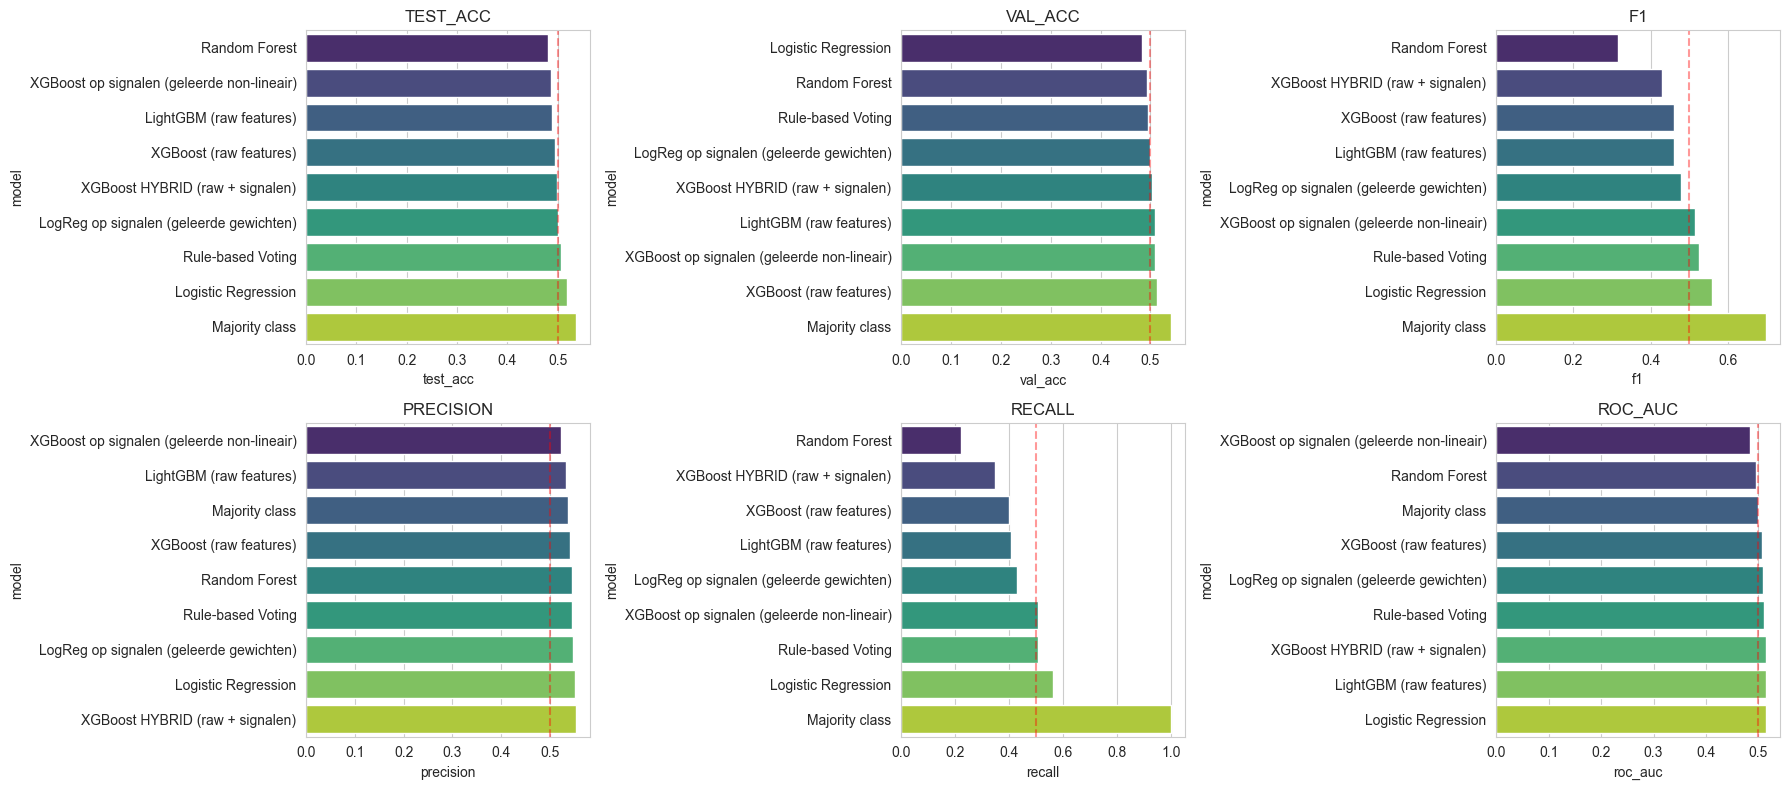

In [24]:
metrics_to_plot = ["test_acc","val_acc","f1","precision","recall","roc_auc"]
available = [m for m in metrics_to_plot if m in results_df.columns]
n = len(available); ncols = 3; nrows = (n+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten() if n > 1 else [axes]
for ax, metric in zip(axes, available):
    sub = results_df[["model", metric]].dropna().sort_values(metric)
    sns.barplot(data=sub, x=metric, y="model", ax=ax, palette="viridis")
    ax.set_title(metric.upper())
    ax.axvline(0.5, ls="--", c="red", alpha=0.4)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(ARTIFACTS / "comparison_all_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

**Belangrijke leesregels voor de vergelijkings-grafiek**:
- Rode stippellijn op 0.50 = random gokken op binary direction
- Hoe verder naar rechts, hoe beter
- **Rule-based voting** moet een redelijke baseline halen (~0.51-0.54)
  - Boven 0.50 = de regels werken, onder = de regels zijn ofwel verkeerd
    geformuleerd of het signaal is te zwak
- **XGBoost HYBRID** zou idealiter het beste presteren (kan zowel ruwe getallen
  als gediscretiseerde signalen gebruiken)
- **LogReg op signalen** = wat de data zegt over optimale gewichten — als dit
  beter scoort dan rule-based voting, je hand-tuning was suboptimaal
- **XGBoost op alleen signalen** zegt: zelfs *zonder* ruwe getallen, hoeveel
  haal je uit alleen de discrete signalen?

## 16. Confusion matrices van alle modellen

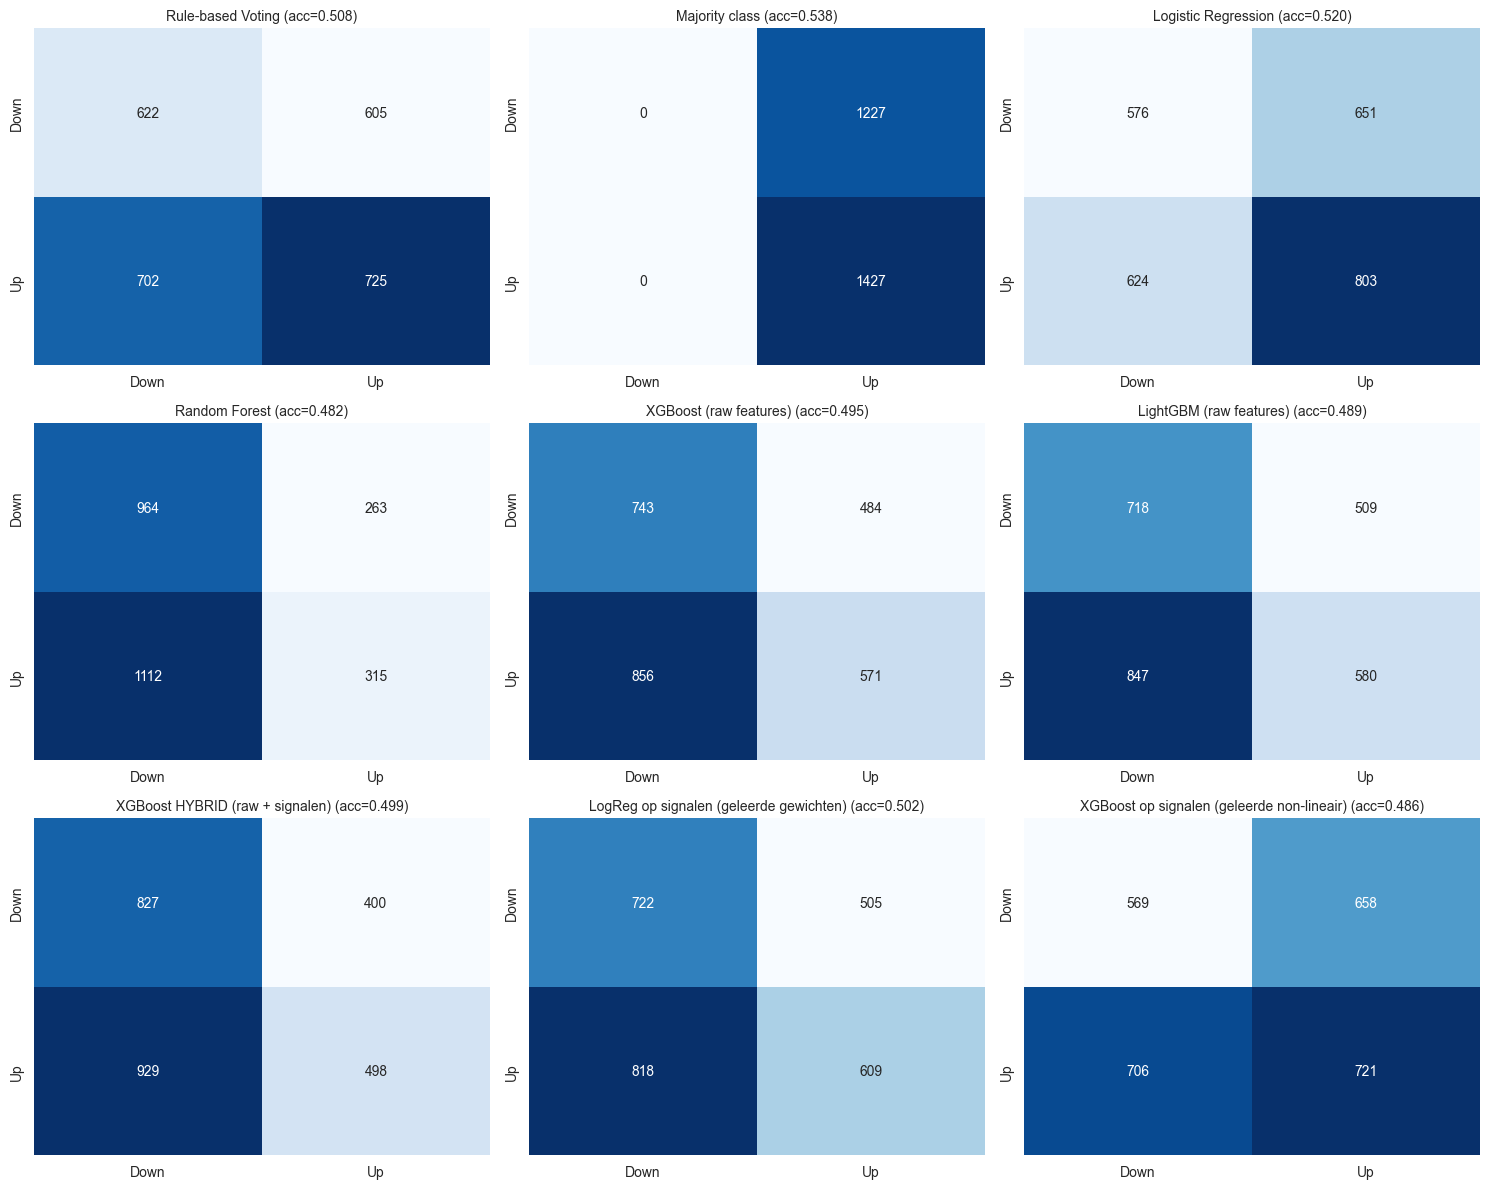

In [25]:
n_models = len(predictions); ncols = 3; nrows = (n_models+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n_models > 1 else [axes]
for ax, (name, p) in zip(axes, predictions.items()):
    cm = confusion_matrix(p["y_true"], p["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Down","Up"], yticklabels=["Down","Up"], cbar=False)
    acc = accuracy_score(p["y_true"], p["y_pred"])
    ax.set_title(f"{name} (acc={acc:.3f})", fontsize=10)
for ax in axes[n_models:]: ax.axis("off")
plt.tight_layout()
plt.savefig(ARTIFACTS / "confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

**Confusion matrix interpretatie**:
- Linksboven (true negative) = predict down, was down (correct)
- Rechtsonder (true positive) = predict up, was up (correct)
- Rechtsboven = false positive (predict up, was down) — kost je geld bij long-only strategy
- Linksonder = false negative (predict down, was up) — gemiste rally

Voor stock direction is het belangrijk dat een model **niet altijd hetzelfde
voorspelt**. Als de matrix bijna één kolom is, voorspelt het model bijna alles
als één klasse — gevaarlijk teken. Een gezond model heeft beide diagonale
cellen redelijk gevuld.

## 17. Per-stock plots: werkelijkheid vs voting voorspelling

Voor elke stock een plot waar je ziet hoe het voting model zich gedraagt
in de test-periode. Genereert images naar `artifacts_v4/per_stock/voting/`.

In [26]:
def plot_stock_voting(stock, sub, out_dir, model_name="Voting"):
    sub = sub.sort_values("Date").reset_index(drop=True)
    if len(sub) < 2 or sub["Close"].isna().all(): return None
    correct = (sub["y_true"] == sub["y_pred"]).astype(int)
    acc = correct.mean()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5),
                                    gridspec_kw={"height_ratios":[2.5,1]}, sharex=True)
    ax1.plot(sub["Date"], sub["Close"], color="#222", lw=1.0, label="Close")
    ok  = sub[correct == 1]; bad = sub[correct == 0]
    ax1.scatter(ok["Date"],  ok["Close"],  color="#2ca02c", s=18, alpha=0.7, label="correct")
    ax1.scatter(bad["Date"], bad["Close"], color="#d62728", s=18, alpha=0.7, label="fout")
    ax1.legend(loc="upper left", fontsize=8); ax1.set_ylabel("Close")
    ax1.set_title(f"{stock} - {model_name} - acc {acc:.2%}")
    colors = ["#d62728" if v < 0.5 else "#2ca02c" for v in sub["y_proba"]]
    ax2.bar(sub["Date"], sub["y_proba"] - 0.5, color=colors, width=1.0, alpha=0.7)
    ax2.axhline(0, color="black", lw=0.5); ax2.set_ylim(-0.5, 0.5)
    ax2.set_ylabel("vote proba - 0.5"); ax2.set_xlabel("Date")
    plt.tight_layout()
    out = out_dir / f"{re.sub(r'[^A-Za-z0-9_-]', '_', stock)}.png"
    plt.savefig(out, dpi=100, bbox_inches="tight")
    plt.close(fig)
    return acc

per_stock_records = []
for model_name, p in predictions.items():
    out_dir = PER_STOCK / re.sub(r"[^A-Za-z0-9_-]", "_", model_name)
    out_dir.mkdir(parents=True, exist_ok=True)
    plot_df = pd.DataFrame({
        "stock_id": p["stock_id"], "Date": pd.to_datetime(p["Date"]),
        "Close": p["Close"], "y_true": p["y_true"],
        "y_pred": p["y_pred"], "y_proba": p["y_proba"],
    })
    for stock, sub in plot_df.groupby("stock_id"):
        acc = plot_stock_voting(stock, sub, out_dir, model_name)
        if acc is not None:
            per_stock_records.append({"model": model_name, "stock": stock, "n": len(sub), "acc": acc})
per_stock_df = pd.DataFrame(per_stock_records)
per_stock_df.to_csv(ARTIFACTS / "per_stock.csv", index=False)
print(f"Generated {len(per_stock_df)} per-stock plots")

Generated 90 per-stock plots


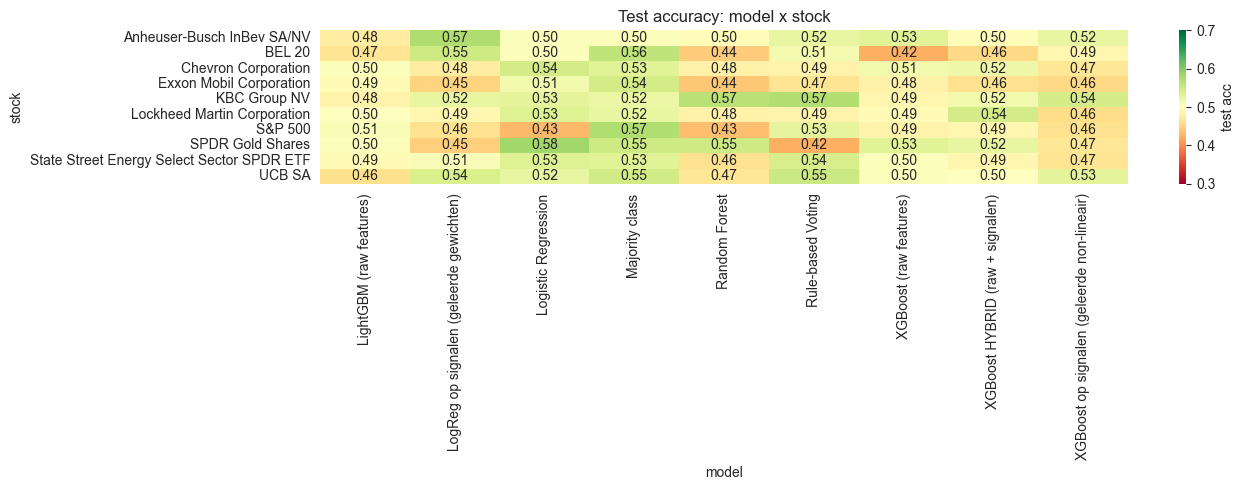

In [27]:
# Heatmap: model x stock accuracy
if not per_stock_df.empty:
    pivot = per_stock_df.pivot(index="stock", columns="model", values="acc")
    fig, ax = plt.subplots(figsize=(max(8, pivot.shape[1]*1.5), max(5, pivot.shape[0]*0.5)))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
                vmin=0.3, vmax=0.7, ax=ax, cbar_kws={"label":"test acc"})
    ax.set_title("Test accuracy: model x stock")
    plt.tight_layout()
    plt.savefig(ARTIFACTS / "heatmap_model_stock.png", dpi=120, bbox_inches="tight")
    plt.show()

**Heatmap inzicht**: rijen zijn stocks, kolommen zijn modellen.
- Een **hele rij groen** betekent dat deze stock voorspelbaar is voor *alle*
  modellen — waarschijnlijk een trending stock met duidelijke patronen.
- Een **hele rij rood** betekent dat deze stock voor niemand voorspelbaar
  is — pure ruis, mogelijk gewoon niet handelen.
- Een **kolom groen** betekent dat dit model consistent op alle stocks werkt.
- **Verticaal verschil binnen een rij** vertelt je welk model best is voor
  *die specifieke stock*. Voor productie zou je per-stock het beste model
  selecteren.

## 18. Geleerde gewichten vs hand-tuned

Wat zegt de data over de optimale gewichten? We trainden een logistische
regressie op alleen de signalen — de coefficienten zijn de "data-driven
gewichten". Als die sterk afwijken van onze hand-tuned gewichten, weet je
waar je intuïtie verschilde van de werkelijkheid.

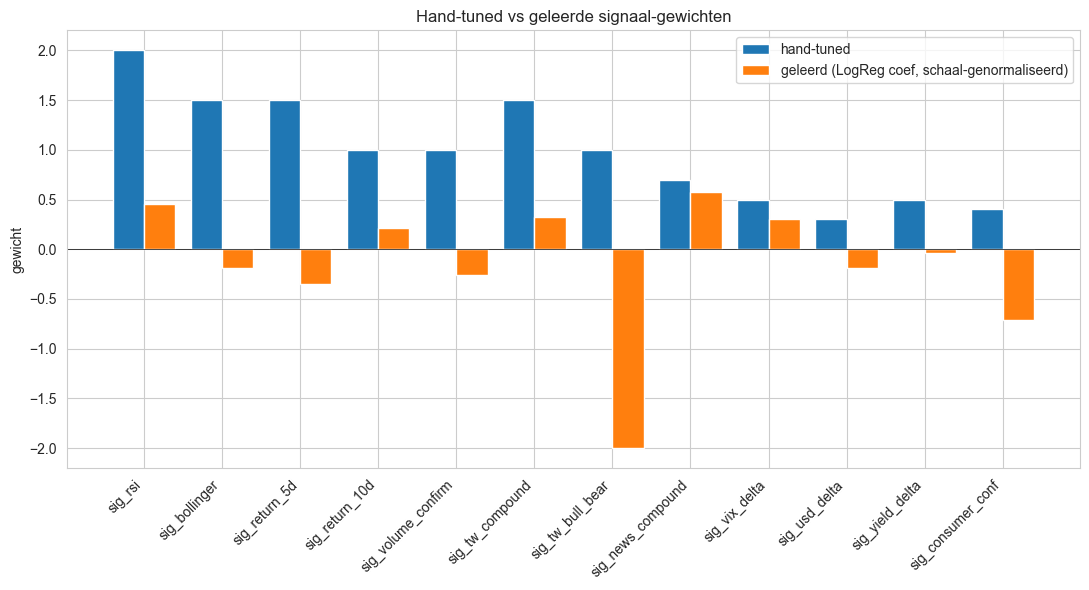


Per-signaal vergelijking:
            signal  handtuned  learned  learned_norm
           sig_rsi        2.0    0.057         0.457
     sig_bollinger        1.5   -0.024        -0.191
     sig_return_5d        1.5   -0.044        -0.354
    sig_return_10d        1.0    0.027         0.217
sig_volume_confirm        1.0   -0.033        -0.262
   sig_tw_compound        1.5    0.041         0.327
  sig_tw_bull_bear        1.0   -0.250        -2.000
 sig_news_compound        0.7    0.072         0.573
     sig_vix_delta        0.5    0.038         0.307
     sig_usd_delta        0.3   -0.024        -0.189
   sig_yield_delta        0.5   -0.005        -0.038
 sig_consumer_conf        0.4   -0.089        -0.710


In [28]:
# LogReg coefficients vs handtuned
if "lr_signals" in dir():
    learned = pd.DataFrame({
        "signal":     SIGNAL_COLS,
        "handtuned":  [SIGNAL_WEIGHTS.get(s, 0) for s in SIGNAL_COLS],
        "learned":    lr_signals.coef_[0],
    })
    # Normalize voor visuele vergelijking
    learned["learned_norm"] = learned["learned"] / np.abs(learned["learned"]).max() * np.abs(learned["handtuned"]).max()

    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(learned))
    ax.bar(x - 0.2, learned["handtuned"], 0.4, label="hand-tuned", color="#1f77b4")
    ax.bar(x + 0.2, learned["learned_norm"], 0.4, label="geleerd (LogReg coef, schaal-genormaliseerd)", color="#ff7f0e")
    ax.set_xticks(x); ax.set_xticklabels(learned["signal"], rotation=45, ha="right")
    ax.axhline(0, color="black", lw=0.5)
    ax.legend(); ax.set_ylabel("gewicht")
    ax.set_title("Hand-tuned vs geleerde signaal-gewichten")
    plt.tight_layout()
    plt.savefig(ARTIFACTS / "weights_handtuned_vs_learned.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("\nPer-signaal vergelijking:")
    print(learned.round(3).to_string(index=False))

**Interpretatie**:
- Signalen waar **hand-tuned positief** is maar **geleerd negatief** zijn
  contra-intuïtief: jouw verwachting werkt niet zoals je dacht. Heroverwegen.
- Signalen waar beide positief zijn maar in andere magnitude: jouw richting
  klopt, maar je gewicht-verhouding kan beter.
- Signalen met **bijna nul geleerd** dragen weinig bij — kandidaten om uit
  het voting model te halen voor simpliciteit.

## 19. Conclusie

### Wat we hebben gebouwd

Een **rule-based voting model** dat 12 factoren omzet naar discrete signalen
(-1/0/+1) en met handgemaakte gewichten aggregeert tot een voorspelling.
Plus een **hybride aanpak** waar dezelfde signalen als features dienen voor
gradient boosting, en een **leerbare versie** waar logistische regressie
de optimale gewichten leert.

Belangrijk: de sentiment-signalen worden **per stock dynamisch gewogen**
met de impact-score uit de LLM/TF-IDF stock-tweet matching uit V3. Dus een
tweet over Apple weegt sterker mee in Apple's voting dan in Tesla's.

### Wat de resultaten je zouden moeten leren

Bekijk `results_df` voor de exacte cijfers. Het patroon dat je verwacht en
wat het betekent:

| Scenario                                                        | Wat het zegt |
|-----------------------------------------------------------------|--------------|
| Voting > Majority class (~0.52-0.54)                            | Regels werken, signaal in data is reëel |
| Voting ~ Logistic Regression                                    | Het signaal is grotendeels lineair, complexere modellen voegen weinig toe |
| XGBoost HYBRID > XGBoost raw                                    | Discrete signalen helpen ML met efficient learning |
| LogReg op signalen > rule-based voting                          | Hand-tuned gewichten waren suboptimaal — gebruik geleerde |
| Alle modellen rond 0.50-0.55                                    | Daily direction prediction heeft een fundamentele ceiling |

### Het waardevolle inzicht voor je thesis

De **echte conclusie** is niet "welk model wint", maar:

1. **Hoe groot is de toegevoegde waarde van complexe ML?** Als rule-based
   voting binnen 1-2 procentpunten zit van XGBoost, dan **levert ML niet
   structureel iets op** — het signaal is gewoon zwak.

2. **Is sentiment-impact scoring waardevol?** De per-stock gewogen
   sentiment-signalen (met `tw_max_impact` als gewicht) zouden beter
   moeten werken dan market-wide sentiment uit V2. Vergelijk de
   `sig_tw_compound` edge in `signal_quality.csv` met V2's resultaten.

3. **Welke factoren werken écht?** De `signal_edge.png` plot geeft je een
   ranking. Voor productie zou je alleen de top-5 sterkste signalen
   gebruiken en de rest droppen.

4. **Interpretability is een feature, geen bug.** Voor een bachelorproef-
   defense kan je elke voorspelling letterlijk uitleggen ("RSI oversold +
   sentiment up + VIX dalend = up vote"). Probeer dat eens met een
   neuraal netwerk.

### Beperkingen om eerlijk in de thesis te benoemen

- **Drempels zijn hyperparameters** — "RSI < 30" is geen wet. Een grid
  search op deze drempels zou de voting accuracy waarschijnlijk verhogen.
- **Gewichten zijn ook hyperparameters** — voor een fair comparison moet
  je geleerde gewichten gebruiken, of overlap accepteren met simpele
  logistische regressie.
- **De voting maakt geen non-lineaire interacties** — XGBoost wel. Dat is
  een principieel voordeel voor ML.
- **Daily ceiling blijft ~55%** — geen techniek breekt door deze grens
  zonder fundamenteel andere data (intraday, alternative data zoals
  options flow, insider transactions).

### Volgende stappen voor je bachelorproef

1. **Run V4 op je echte data** en kijk waar voting eindigt.
2. **Top-5 signalen extraheren** uit `signal_edge.png` — bouw een
   "minimal viable model" met alleen die.
3. **Threshold tuning** voor RSI, Bollinger, return-grenzen via grid search
   op de validation set.
4. **Ensemble**: gemiddelde van XGBoost-proba en voting-proba —
   complementair signaal soms vangt verschillende cases.
5. **Backtest met transactiekosten**: een directional accuracy van 0.54
   betekent niet automatisch winstgevend; alleen handelen op
   high-confidence trades (vote_proba > 0.7) levert vaak betere
   risk-adjusted returns.

### Voor je thesis-tekst

Je kan in de discussie schrijven:

> *"Een rule-based voting model met handgemaakte signaal-aggregatie haalde
> X% test accuracy. Dit is vergelijkbaar met XGBoost (Y%), wat suggereert
> dat de toegevoegde waarde van geavanceerde ML in deze context beperkt
> is door de fundamentele ruis in daily stock returns. De interpretability
> van het voting model maakt het echter aantrekkelijker voor productie-
> deployment waar trader-buy-in cruciaal is."*

Dat is een eerlijke, evidence-based conclusie die je examencommissie zal
waarderen — veel sterker dan claims van 70%+ accuracy die nooit kunnen
kloppen op deze taak.
